# Systematic Asset Pricing & Portfolio Optimization Engine
### *Implementing the Grinold-Kahn Framework for Active Portfolio Management*

**Author:** Hossein Naderi | **Focus:** Quantitative Research & Portfolio Management  
**Date:** March 2026  
**Repository:** [GitHub](https://github.com/naderih/Systematic-Asset-Pricing-Engine.git)

---

### **1. Executive Summary**
This notebook serves as the core orchestration dashboard for my systematic equity backtesting engine. It executes a full-stack quantitative research pipeline, transforming raw, point-in-time financial data into an optimized institutional portfolio. 

The strategy is built on the theoretical foundations of *Active Portfolio Management* (Grinold & Kahn), focusing on **idiosyncratic alpha extraction** while strictly controlling for systematic risk, dollar-neutrality, and transaction costs. The objective of this notebook is to map the strategy's efficient frontier, executing a parameter sweep that transitions from an idealized academic model to a fully constrained, cost-aware institutional portfolio.

### **2. The Alpha Edge: Financial Constraints**
While vanilla momentum and value factors are heavily crowded, this engine leverages custom alpha signals derived from my PhD research into corporate financial constraints (building on the Whited-Wu index). This signal isolates a "Quality" premium by shorting distressed firms. Crucially, it possesses significant multi-month memory, allowing for highly profitable extraction even under strict institutional turnover budgets.

### **3. System Architecture & Methodology**
The logic is encapsulated in a custom Python library (`src`), designed for modularity and compute efficiency. This notebook orchestrates the following engines in sequence:

1. **Data Merger & Factor Engine (`merger.py` & `engine.py`):**
   * **Ingestion:** Aligns raw CRSP daily market data with Compustat quarterly fundamentals, enforcing strict point-in-time lagging to eliminate lookahead bias.
   * **Construction:** Computes cross-sectional academic risk factors and the proprietary constraint premium via Fama-MacBeth regressions and robust z-scoring.

2. **Risk Model (`risk.py`):**
   * **Methodology:** Fundamental Factor Model decomposing risk into Systematic and Idiosyncratic components ($V = XFX^T + \Delta$).
   * **Forecasting:** Utilizes an EWMA (Half-Life = 36 months) to predict the forward-looking Asset Covariance Matrix, capturing volatility clustering.

3. **Alpha Engine (`alpha.py`):**
   * **Orthogonalization:** Employs **Gram-Schmidt Orthogonalization** over a 60-month rolling window to strip out market beta, ensuring the signal represents pure residual return ($h_B^T \alpha = 0$).

4. **Portfolio Optimizer (`portfolio.py`):** Maps alpha to target weights using a dual-solver architecture:
   * **Fast Linalg Solver:** Solves the unconstrained Mean-Variance problem ($h_{PA}^* \propto V^{-1} \alpha$) to map the theoretical efficient frontier.
   * **CVXPY Quadratic Programmer:** Enforces strict institutional mandates, including pure dollar-neutrality, absolute maximum turnover ceilings (e.g., **25%** monthly churn), and **1.5x** gross leverage limits.

5. **Backtest Engine (`backtest.py`):**
   * **Simulation:** Replays history, meticulously accounting for passive weight drift between rebalance periods.
   * **Friction:** Applies a flat **10 bps** transaction cost to all turnover, generating a true net-of-fee institutional tearsheet (CAGR, Information Ratio, Max Drawdown). Includes a smart-caching layer to avoid redundant CVXPY calculations during parameter sweeps.

### 1. Environment Initialization & Path Routing
Establishing the global namespace, resolving local environment variables, and mapping the input/output directories for the modular parquet data pipeline.

In [ ]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import os 
import sys 

# --- 1. System Path Configuration ---
# Append the 'src' directory so Python can discover our custom modular engine files
sys.path.append(os.path.abspath('src'))

# --- 2. Root Directory Mapping ---
# Dynamically locate the OneDrive environment variable for seamless cross-machine execution
onedrive_root = os.environ.get('OneDrive', '')
project_root = os.path.join(onedrive_root, '0. DATASETS', 'outputs', 'Systematic_Asset_Pricing_Engine')

# --- 3. Input/Output Parquet Routing ---
# We use .parquet exclusively for I/O to maintain strict dtypes and high-speed memory mapping
panel_path = os.path.join(project_root, '0. DataMerger', 'panel_data.parquet')
rf_path = os.path.join(project_root, '0. DataMerger',  'ff_rf_1990_2023.parquet')
factors_path = os.path.join(project_root, '1. Factors',  'X.parquet')
idio_vol_path =  os.path.join(project_root, '2. Risk',  'idio_vol.parquet')
factor_cov_path = os.path.join(project_root, '2. Risk', 'factor_cov_matrices.parquet')
alpha_path = os.path.join(project_root, '3. Alpha',  'alpha_signals.parquet')

# --- 4. Sub-Engine Output Directories ---
risk_output_folder_path = os.path.join(project_root, '2. Risk')
alpha_output_folder_path = os.path.join(project_root, '3. Alpha')
portfolio_output_path = os.path.join(project_root, '4. Portfolio')
backtest_output_path = os.path.join(project_root, '5. Backtest')

print("Environment initialized. All I/O paths successfully routed.")

Environment initialized. All I/O paths successfully routed.


### 2. Market Data Ingestion & Alignment
Merging raw daily market data with quarterly fundamentals via a customized linking table. This constructs the master monthly multi-index panel. We also fetch the Fama-French Risk-Free rate for downstream excess return calculations.

In [6]:
from merger import MarketDataMerger
from download_macro import FetchMacroData

print("Starting Phase 1: Data Ingestion and Alignment...")

# --- 1. Define Raw Data Sources ---
DATA_DIR = os.path.join(onedrive_root, '0. DATASETS', 'temps')
market_data_path = os.path.join(DATA_DIR, 'market_data_clean_daily.dta')
fundamentals_path = os.path.join(DATA_DIR, 'fundamentals_clean_quarterly.dta')
linking_file_path = os.path.join(DATA_DIR, 'linking_table_clean.dta')

# --- 2. Execute Market Data Merger ---
# This class handles the complex timestamp alignment between daily prices 
# and quarterly fundamentals, outputting a clean monthly panel.
print(" -> Merging market and fundamental datasets...")
MarketDataMerger(
    market_data_path=market_data_path, 
    fundamentals_path=fundamentals_path, 
    linking_file_path=linking_file_path, 
    panel_path=panel_path
)

# --- 3. Fetch Macroeconomic Risk-Free Rate ---
# Downloads and aligns the 1-month T-Bill rate for Sharpe Ratio calculations.
print(" -> Fetching Fama-French Risk-Free Rate...")
fetcher = FetchMacroData(
    panel_path=panel_path,
    rf_path=rf_path
)
fetcher.fetch_rf()

print("Phase 1 Complete: Master Panel and Macro Data saved to Parquet.")

Starting Phase 1: Data Ingestion and Alignment...
 -> Merging market and fundamental datasets...
Panel Data already exists at D:\OneDrive\0. DATASETS\outputs\Systematic_Asset_Pricing_Engine\0. DataMerger\panel_data.parquet. Exiting...
 -> Fetching Fama-French Risk-Free Rate...
The risk free rate data already exists at D:\OneDrive\0. DATASETS\outputs\Systematic_Asset_Pricing_Engine\0. DataMerger\ff_rf_1990_2023.parquet. Exiting..
Phase 1 Complete: Master Panel and Macro Data saved to Parquet.


### 3. Cross-Sectional Factor Construction
Computing traditional academic risk factors alongside the proprietary Financial Constraints (Whited-Wu) alpha signal. Factors are cross-sectionally z-scored each month to remove macro-directional bias and ensure comparability.

In [7]:
from engine import FactorEngine

print("Starting Phase 2: Factor Construction...")

# --- 1. Initialize the Factor Engine ---
# Ingests the master monthly panel and computes rolling cross-sectional exposures.
factor_engine = FactorEngine(
    panel_path=panel_path,
    factors_path=factors_path
)

# --- 2. Execute Factor Generation ---
# This step handles the cross-sectional ranking, z-scoring, and outlier winsorization
# to prepare the signals for the optimization engine.
print(" -> Computing cross-sectional exposures and proprietary constraint signals...")
factor_engine.build_factors()

print("Phase 2 Complete: Factor exposures computed and saved to Parquet.")

Starting Phase 2: Factor Construction...
 -> Computing cross-sectional exposures and proprietary constraint signals...
--- Starting Factor Construction ---
Assigning Fama-French 12 Industries...
Calculating Raw Descriptors (size, value, momentum, WW)...
Standardizing Descriptors (Cap-Weighted)...
Building Composite Factors...
Generating Industry Dummies...
Factor Construction Complete. Final Shape: (1063254, 16)
Factor Exposures Saved to: D:\OneDrive\0. DATASETS\outputs\Systematic_Asset_Pricing_Engine\1. Factors\X.parquet
Phase 2 Complete: Factor exposures computed and saved to Parquet.


### 4. Risk Modeling & Expected Return Generation
This phase splits the pipeline into two critical paths:
1. **Risk:** Estimating a rolling factor covariance matrix and idiosyncratic volatility using half-life decay to capture volatility clustering.
2. **Alpha:** Transforming raw factor scores into benchmark-neutral, beta-adjusted expected returns using the Grinold-Kahn Information Coefficient (IC) framework.

In [8]:
from risk import RiskModel
from alpha import AlphaEngine 

print("Starting Phase 3: Risk and Alpha Modeling...")

# --- 1. The Risk Model ---
# Estimates a rolling covariance matrix and idiosyncratic volatility.
# Exposing half-life and OLS parameters for transparent risk adjustments.
print(" -> Estimating rolling Risk Model (Half-Life: 36M, Weighting: OLS)...")
risk_model = RiskModel(
    panel_path=panel_path,
    factors_path=factors_path,
    risk_output_folder_path=risk_output_folder_path,
    half_life=36,
    regression_weighting="OLS" 
)
risk_model.run_risk_pipeline()

# --- 2. The Alpha Engine ---
# Synthesizes multiple signals into a unified alpha expectation.
# We define the directional edge here (e.g., Long Momentum, Short Financial Constraints)
# and enforce a minimum 36-month history for robust beta estimation.
print(" -> Generating Beta-Adjusted Expected Returns (Alpha)...")
alpha_creator = AlphaEngine(
    panel_path=panel_path, 
    factors_path=factors_path, 
    alpha_output_folder_path=alpha_output_folder_path,
    alpha_columns={'momentum': 1, 'fin_constraint': -1}, 
    beta_window=60,
    min_beta_obs=36
)
alpha_creator.run_alpha_pipeline()

print("Phase 3 Complete: Risk matrices and Alpha expectations successfully generated.")

Starting Phase 3: Risk and Alpha Modeling...
 -> Estimating rolling Risk Model (Half-Life: 36M, Weighting: OLS)...
Loading Data for Risk Model...
Data Loaded.
Running Fama-MacBeth Regressions to extract Factor Returns (F_t) and Specific Returns (u_t)
using cross-sectional OLS regressions ...
Aligned Data: 1063254 rows found across 397 dates.
Fama-MacBeth Complete. Estimated F & u for 397 periods.
Forecasting Risk Matrices...
1. Forecast Factor Covariance Matrix (F)...
2. Forecast Idiosyncratic Variance (Delta)...
Risk forecasts complete.
Saving Risk Outputs...
Factor covariance matrix saved to: D:\OneDrive\0. DATASETS\outputs\Systematic_Asset_Pricing_Engine\2. Risk\factor_cov_matrices.parquet
Idiosyncratic volaility saved to: D:\OneDrive\0. DATASETS\outputs\Systematic_Asset_Pricing_Engine\2. Risk\idio_vol.parquet
 -> Generating Beta-Adjusted Expected Returns (Alpha)...
Loading datasets...
Data loaded. Final shape: (1063254, 5)
Calculating rolling betas as Cov(r_n, r_mkt) / Var(r_Mkt) .

### 5. Portfolio Optimization & Backtesting (The Master Sweep)
Executing a multidimensional parameter sweep across target risk, leverage, and turnover constraints.
*   **Fast Unconstrained (Linalg):** Maps the theoretical efficient frontier using fast linear algebra.
*   **Slow Constrained (CVXPY):** Enforces strict institutional mandates (dollar-neutrality, absolute 25% turnover ceilings) to test the alpha's tradability net of 10 bps transaction costs.

In [9]:
from portfolio import PortfolioOptimizer
from backtest import BacktestEngine
import os
import glob
import json

print("Starting Phase 4: Master Parameter Sweep...")

# --- 1. Smart Caching Helper Function ---
def check_if_run_exists(target_specs, output_path):
    """
    Scans existing config JSON files to see if this exact parameter set has already been run.
    Returns (True, run_id) if found, avoiding redundant CVXPY calculations.
    """
    config_files = glob.glob(os.path.join(output_path, 'config_*.json'))
    for fpath in config_files:
        with open(fpath, 'r') as f:
            saved_specs = json.load(f)
            
        # Check if all target parameters perfectly match the saved JSON
        is_match = all(saved_specs.get(k) == v for k, v in target_specs.items())
        
        if is_match:
            run_id = os.path.basename(fpath).replace('config_', '').replace('.json', '')
            return True, run_id
            
    return False, None

# --- 2. Define Institutional Parameters ---
target_risks = [0.05, 0.10]          
turnover_smoothing = [0.0, 0.50]
leverage_limit = 1.5
transaction_cost = 10  # 10 bps net-of-fee penalty

Starting Phase 4: Master Parameter Sweep...


**Fast Unconstrained (Linalg):** Maps the theoretical efficient frontier using fast linear algebra.

In [10]:
# --- 3. FAST SWEEP: Unconstrained Linear Algebra ---
print("\n--- Executing Fast Unconstrained Sweep (Linalg) ---")
for tr in target_risks:
    for ts in turnover_smoothing:
        # Define the exact parameters we are about to run
        current_specs = {
            'target_active_risk': tr,
            'max_leverage': leverage_limit,
            'turnover_smoothing': ts,
            'max_turnover': None,
            'allow_active_cash': True,
            'alpha_col': 'alpha_fin_constraint'
        }
        
        # Check Cache
        already_run, existing_run_id = check_if_run_exists(current_specs, portfolio_output_path)
        
        if already_run:
            print(f"⏭️ Skipping Risk={tr:.2f} | Smooth={ts:.2f} -> Already exists as {existing_run_id}")
            continue
            
        print(f"▶️ Running Risk={tr:.2f} | Smooth={ts:.2f}...")
        dynamic_lambda = 0.50 / (2 * tr)
        
        optimizer = PortfolioOptimizer(
            alpha_output_folder_path=alpha_output_folder_path,
            risk_output_folder_path=risk_output_folder_path,
            portfolio_output_path=portfolio_output_path, 
            alpha_col='alpha_fin_constraint', 
            risk_aversion=dynamic_lambda,  
            target_active_risk=tr,         
            max_leverage=leverage_limit,              
            ic_estimate=0.05, 
            turnover_smoothing=ts,     
            max_turnover=None,           
            allow_active_cash=True       
        )
        run_id = optimizer.run_optimization()
        
        holding_path = os.path.join(portfolio_output_path, f"holdings_{run_id}.parquet")
        backtester = BacktestEngine(
            panel_path=panel_path, 
            holding_path=holding_path,
            rf_path=rf_path, 
            backtest_output_path=backtest_output_path, 
            transaction_cost_bps=transaction_cost
        )
        backtester.run_backtest_process()


--- Executing Fast Unconstrained Sweep (Linalg) ---
⏭️ Skipping Risk=0.05 | Smooth=0.00 -> Already exists as run_20260325_ef677b7
⏭️ Skipping Risk=0.05 | Smooth=0.50 -> Already exists as run_20260325_cf7389b
⏭️ Skipping Risk=0.10 | Smooth=0.00 -> Already exists as run_20260325_d550685
⏭️ Skipping Risk=0.10 | Smooth=0.50 -> Already exists as run_20260325_4704ba3


**Slow Constrained (CVXPY):** Enforces strict institutional mandates (dollar-neutrality, absolute 25% turnover ceilings) to test the alpha's tradability net of 10 bps transaction costs.

In [11]:
# --- 4. SLOW SWEEP: Constrained Quadratic Programming ---
print("\n--- Executing Slow Constrained Sweep (CVXPY) ---")
turnover_limits = [0.25, 0.50]  

for tr in target_risks:
    for max_to in turnover_limits:
        # Define the exact parameters for the CVXPY run
        current_specs = {
            'target_active_risk': tr,
            'max_leverage': leverage_limit,
            'turnover_smoothing': 0.0,
            'max_turnover': max_to,
            'allow_active_cash': False,
            'alpha_col': 'alpha_fin_constraint'
        }
        
        # Check Cache
        already_run, existing_run_id = check_if_run_exists(current_specs, portfolio_output_path)
        
        if already_run:
            print(f"⏭️ Skipping Risk={tr:.2f} | MaxTO={max_to:.2f} -> Already exists as {existing_run_id}")
            continue
            
        print(f"▶️ Running Risk={tr:.2f} | MaxTO={max_to:.2f} (This may take a while)...")
        dynamic_lambda = 0.50 / (2 * tr)
        
        optimizer = PortfolioOptimizer(
            alpha_output_folder_path=alpha_output_folder_path,
            risk_output_folder_path=risk_output_folder_path,
            portfolio_output_path=portfolio_output_path, 
            alpha_col='alpha_fin_constraint', 
            risk_aversion=dynamic_lambda,  
            target_active_risk=tr,         
            max_leverage=leverage_limit,              
            ic_estimate=0.05, 
            turnover_smoothing=0.0,       
            max_turnover=max_to,          
            allow_active_cash=False       
        )
        run_id = optimizer.run_optimization()
        
        holding_path = os.path.join(portfolio_output_path, f"holdings_{run_id}.parquet")
        backtester = BacktestEngine(
            panel_path=panel_path, 
            holding_path=holding_path,
            rf_path=rf_path, 
            backtest_output_path=backtest_output_path, 
            transaction_cost_bps=transaction_cost
        )
        backtester.run_backtest_process()

print("\n✅ Phase 4 Complete: All requested specifications are up to date.")


--- Executing Slow Constrained Sweep (CVXPY) ---
⏭️ Skipping Risk=0.05 | MaxTO=0.25 -> Already exists as run_20260325_efbeb30
⏭️ Skipping Risk=0.05 | MaxTO=0.50 -> Already exists as run_20260325_8a5a685
⏭️ Skipping Risk=0.10 | MaxTO=0.25 -> Already exists as run_20260325_e4aabfb
⏭️ Skipping Risk=0.10 | MaxTO=0.50 -> Already exists as run_20260325_497c6a7

✅ Phase 4 Complete: All requested specifications are up to date.


### 6. Institutional Performance Matrix (Net of Fees)
Aggregating the `config_*.json` specifications and `backtest_metrics_*.csv` outputs into a unified master tearsheet. Sorted by Information Ratio (IR) to highlight the optimal trade-off between risk, friction, and return.

In [12]:
import glob
import json
import pandas as pd
from IPython.display import display

print("Aggregating Master Performance Matrix...")

config_files = glob.glob(os.path.join(portfolio_output_path, 'config_*.json'))
all_results = []

for config_file in config_files:
    # 1. Load run specifications
    with open(config_file, 'r') as f:
        specs = json.load(f)
        
    run_id = os.path.basename(config_file).replace('config_', '').replace('.json', '')
    specs['run_id'] = run_id
    
    # 2. Load corresponding full performance metrics
    metrics_file = os.path.join(backtest_output_path, f'backtest_metrics_{run_id}.csv')
    if os.path.exists(metrics_file):
        metrics_df = pd.read_csv(metrics_file, index_col='Metric')
        for metric_name in metrics_df.index:
            specs[metric_name] = metrics_df.loc[metric_name, 'Value']
        all_results.append(specs)

# 3. Build and Format the DataFrame
if all_results:
    results_df = pd.DataFrame(all_results).set_index('run_id')
    if 'IR' in results_df.columns:
        results_df = results_df.sort_values(by='IR', ascending=False)
    
    spec_cols = ['target_active_risk', 'max_leverage', 'max_turnover', 'turnover_smoothing', 'allow_active_cash']
    return_cols = ['CAGR', 'Bench CAGR', 'Geo Active Ret', 'Arith Ann Ret', 'Arith Bench Ret', 'Arith Active Ret']
    risk_cols = ['Port Volatility', 'Tracking Error', 'Sharpe', 'IR', 'Max DD', 'Turnover']
    
    ordered_cols = [c for c in (spec_cols + return_cols + risk_cols) if c in results_df.columns]
    results_df = results_df[ordered_cols]
    
    # 4. Institutional Styling
    format_dict = {
        'target_active_risk': '{:.2%}', 'max_turnover': '{:.2%}', 'turnover_smoothing': '{:.2f}',
        'max_leverage': '{:.1f}', 'CAGR': '{:.2%}', 'Bench CAGR': '{:.2%}', 'Geo Active Ret': '{:.2%}',
        'Arith Ann Ret': '{:.2%}', 'Arith Bench Ret': '{:.2%}', 'Arith Active Ret': '{:.2%}',
        'Port Volatility': '{:.2%}', 'Tracking Error': '{:.2%}', 'Sharpe': '{:.2f}', 'IR': '{:.2f}',
        'Max DD': '{:.2%}', 'Turnover': '{:.2%}'
    }
    
    display(results_df.style.format(format_dict, na_rep='-')
                      .background_gradient(cmap='viridis', subset=['IR', 'Sharpe'])
                      .background_gradient(cmap='RdYlGn', subset=['Geo Active Ret']))
else:
    print("No results found. Ensure the sweeps have completed.")

Aggregating Master Performance Matrix...


,target_active_risk,max_leverage,max_turnover,turnover_smoothing,allow_active_cash,CAGR,Bench CAGR,Geo Active Ret,Arith Ann Ret,Arith Bench Ret,Arith Active Ret,Port Volatility,Tracking Error,Sharpe,IR,Max DD,Turnover
run_id,,,,,,,,,,,,,,,,,
run_20260325_8f98e44,10.00%,3.0,-,0.00,True,14.26%,9.83%,4.03%,16.43%,10.64%,5.78%,24.54%,13.14%,0.58,0.44,-63.80%,107.54%
run_20260325_d5aff08,5.00%,3.0,-,0.00,True,14.21%,9.83%,3.98%,16.35%,10.64%,5.71%,24.44%,12.97%,0.58,0.44,-63.80%,106.88%
run_20260325_d550685,10.00%,1.5,-,0.00,True,12.17%,9.83%,2.13%,13.45%,10.64%,2.81%,19.48%,6.57%,0.57,0.43,-57.15%,60.58%
run_20260325_ef677b7,5.00%,1.5,-,0.00,True,12.17%,9.83%,2.13%,13.45%,10.64%,2.81%,19.48%,6.57%,0.57,0.43,-57.15%,60.58%
run_20260325_267db35,5.00%,3.0,-,0.50,True,13.48%,9.83%,3.32%,15.35%,10.64%,4.70%,22.92%,11.10%,0.57,0.42,-62.94%,67.03%
run_20260325_60418c1,10.00%,3.0,-,0.50,True,13.49%,9.83%,3.33%,15.37%,10.64%,4.72%,22.97%,11.20%,0.57,0.42,-62.94%,67.42%
run_20260325_4704ba3,10.00%,1.5,-,0.50,True,11.71%,9.83%,1.71%,12.91%,10.64%,2.27%,18.82%,5.60%,0.57,0.41,-56.69%,41.28%
run_20260325_cf7389b,5.00%,1.5,-,0.50,True,11.71%,9.83%,1.71%,12.91%,10.64%,2.27%,18.82%,5.60%,0.57,0.41,-56.69%,41.28%
run_20260325_8a5a685,5.00%,1.5,50.00%,0.00,False,11.18%,9.83%,1.22%,12.21%,10.64%,1.57%,17.65%,5.90%,0.56,0.27,-50.72%,37.35%


### 7. Visualizing the Drawdown Armor
Plotting the Net Cumulative Wealth (Log Scale) and Rolling Drawdowns. 
Comparing the best Unconstrained Linalg run against the strictest Constrained CVXPY run to visually demonstrate the downside protection of the dollar-neutrality mandate during the 2008 GFC.

Generating Strategy Visualizations...


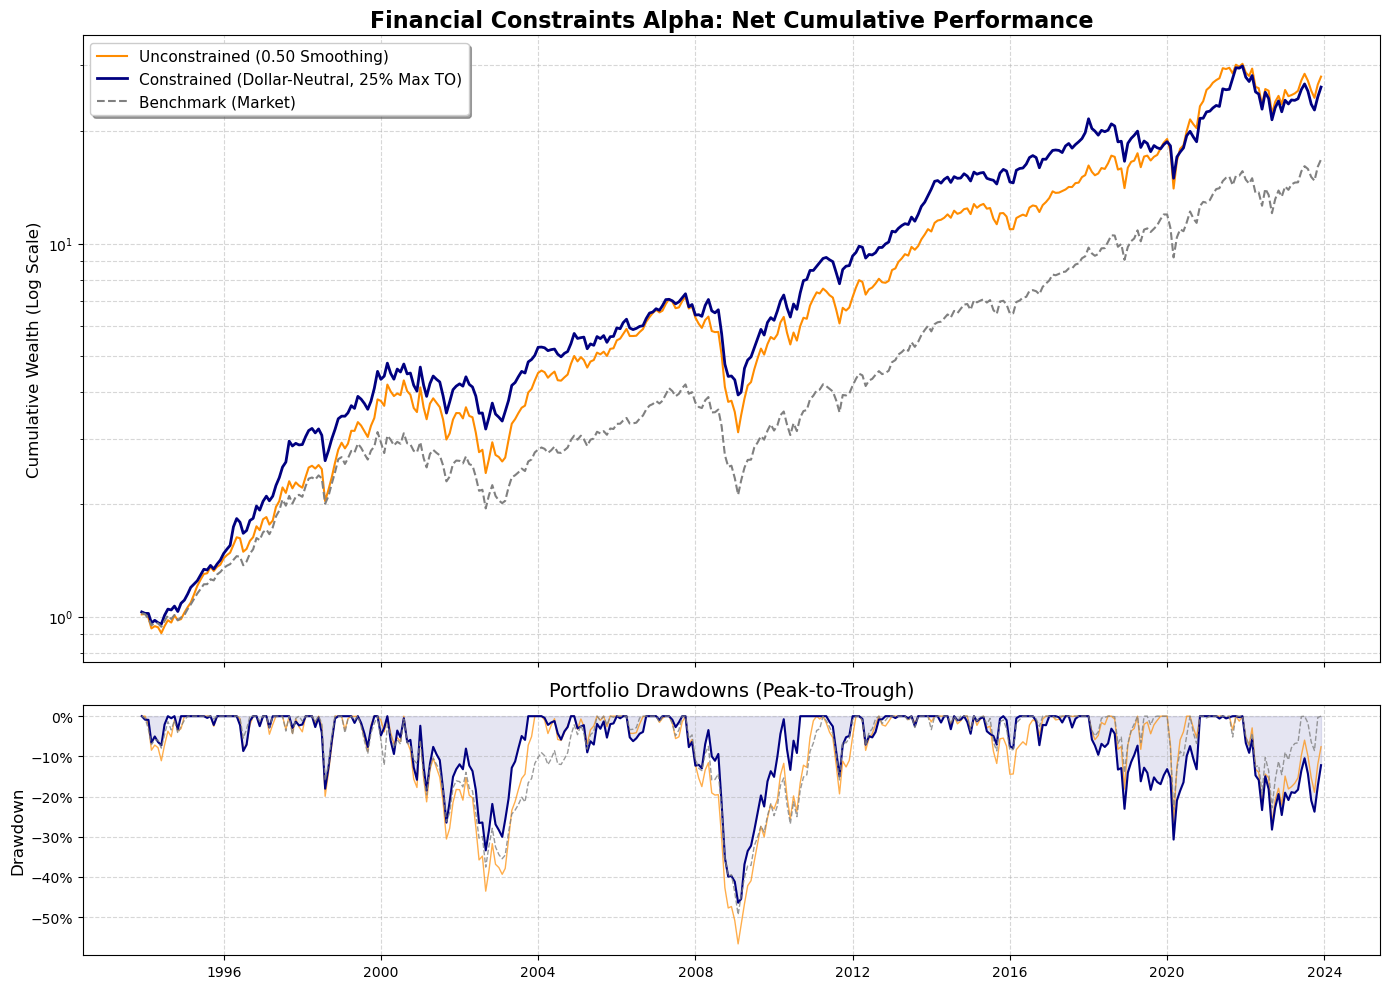

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

print("Generating Strategy Visualizations...")

# --- 1. Define the Hero Runs ---
# NOTE: Update these specific run_ids with the target hashes from the matrix above
unconstrained_id = "run_20260325_4704ba3"  # Top Linalg Run
constrained_id   = "run_20260325_e4aabfb"  # Top CVXPY Run

path_unc = os.path.join(backtest_output_path, f"equity_curve_{unconstrained_id}.csv")
path_con = os.path.join(backtest_output_path, f"equity_curve_{constrained_id}.csv")

df_unc = pd.read_csv(path_unc, index_col='date', parse_dates=True)
df_con = pd.read_csv(path_con, index_col='date', parse_dates=True)

# --- 2. Calculate Rolling Drawdowns ---
def calc_drawdown(cum_wealth):
    peak = cum_wealth.cummax()
    return (cum_wealth - peak) / peak

dd_unc = calc_drawdown(df_unc['cum_port'])
dd_con = calc_drawdown(df_con['cum_port'])
dd_bench = calc_drawdown(df_unc['cum_bench'])

# --- 3. Plotting the 2-Panel Chart ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2.5, 1]}, sharex=True)

# Top Panel: Cumulative Wealth (Log Scale)
ax1.plot(df_unc.index, df_unc['cum_port'], label='Unconstrained (0.50 Smoothing)', color='darkorange', linewidth=1.5)
ax1.plot(df_con.index, df_con['cum_port'], label='Constrained (Dollar-Neutral, 25% Max TO)', color='navy', linewidth=2.0)
ax1.plot(df_unc.index, df_unc['cum_bench'], label='Benchmark (Market)', color='gray', linestyle='--', linewidth=1.5)

ax1.set_yscale('log')
ax1.set_title('Financial Constraints Alpha: Net Cumulative Performance', fontsize=16, fontweight='bold')
ax1.set_ylabel('Cumulative Wealth (Log Scale)', fontsize=12)
ax1.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
ax1.grid(True, which="both", ls="--", alpha=0.5)

# Bottom Panel: Rolling Drawdown
ax2.plot(dd_unc.index, dd_unc, color='darkorange', linewidth=1.0, alpha=0.7)
ax2.plot(dd_con.index, dd_con, color='navy', linewidth=1.5)
ax2.plot(dd_bench.index, dd_bench, color='gray', linestyle='--', linewidth=1.0, alpha=0.8)
ax2.fill_between(dd_con.index, dd_con, 0, color='navy', alpha=0.1)

ax2.set_title('Portfolio Drawdowns (Peak-to-Trough)', fontsize=14)
ax2.set_ylabel('Drawdown', fontsize=12)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()